# Data Enrichment EDA — Authors, Citations, Venues, Notes

**ELI5:** this notebook answers four specific descriptive questions about
`data/processed/papers_combined.parquet` (the cleaned, combined output of
`data_compile/combine_use_cases.ipynb`), each broken down by use case and by label:

1. What does the `notes` field generally contain?
2. How many authors does a paper generally have?
3. How many citations does a paper generally have?
4. What are the most common venues?

This is descriptive only — read-only, no files written back to `data/`. It's meant to
surface candidate metadata features (author count, citation count, venue) for Week 2
feature engineering, and to document what the free-text `notes` field is actually for.

A note on "label": `review_label` is populated for only 1 of 2,873 rows (see
`explore_use_cases.ipynb` § 1c), so a `review_label` breakdown would be one giant empty
bucket dressed up as a table. Every "by label" breakdown below uses `triage_label`
instead — the only label column with real variance — and this is called out once here
rather than repeated at every section.

In [1]:
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

DATA_PATH = Path("../../data/processed/papers_combined.parquet")

# Same palette as explore_use_cases.ipynb / explore_usecase_definitions.ipynb, so the
# label/use-case color language stays identical across every EDA notebook in the repo.
LABEL_COLORS = {"positive": "#2ca02c", "negative": "#d62728", "pass": "#9467bd"}
UNLABELLED_COLOR = "#c7c7c7"
USE_CASE_COLORS = ["#2a78d6", "#1baf7a", "#eda100", "#4a3aa7", "#e87ba4", "#eb6834"]

plt.rcParams.update({
    "axes.spines.top": False,
    "axes.spines.right": False,
    "axes.edgecolor": "#c3c2b7",
    "axes.labelcolor": "#52514e",
    "xtick.color": "#52514e",
    "ytick.color": "#52514e",
    "text.color": "#0b0b0b",
    "axes.grid": True,
    "grid.color": "#e1e0d9",
    "grid.linewidth": 0.6,
    "axes.axisbelow": True,
    "font.size": 10,
})

df = pd.read_parquet(DATA_PATH)
USE_CASE_ORDER = sorted(df["use_case_key"].unique())
USE_CASE_COLOR_MAP = dict(zip(USE_CASE_ORDER, USE_CASE_COLORS))
LABEL_ORDER = ["positive", "negative", "pass"]  # NaN ("never triaged") handled separately

print(f"Loaded {len(df)} rows x {len(df.columns)} columns from {DATA_PATH.name}")
print(f"Use cases ({len(USE_CASE_ORDER)}): {USE_CASE_ORDER}")
print(f"triage_label counts:\n{df['triage_label'].value_counts(dropna=False)}")

Loaded 2873 rows x 50 columns from papers_combined.parquet
Use cases (6): ['carbon_capture', 'cement_binders', 'ner', 'soil_microbiome', 'solar_leo', 'tech_forecasting']
triage_label counts:
triage_label
positive    1067
negative     785
pass         543
NaN          478
Name: count, dtype: int64


## 1. What does `notes` generally contain?

`notes` is broadcast from each use case's `usecase.json` search-brief definition (see
`combine_use_cases.ipynb` step 5) — it's the same string for every paper row within a
use case, not a per-paper field. So "generally" here means *per use case*, and a
null/non-null count would just report 100% or 0% within each use case — not useful.
The question worth asking instead: how many use cases actually have one, and what kind
of content is in it?

In [2]:
notes_by_uc = (
    df.drop_duplicates("use_case_key")[["use_case_key", "use_case_name", "notes"]]
    .assign(has_notes=lambda d: d["notes"].str.strip().str.len() > 0,
            word_count=lambda d: d["notes"].str.split().str.len().fillna(0).astype(int))
    .sort_values("use_case_key")
    .reset_index(drop=True)
)
print(f"{notes_by_uc['has_notes'].sum()} / {len(notes_by_uc)} use cases have a non-empty notes field.\n")
for _, row in notes_by_uc.iterrows():
    preview = row["notes"][:160] + ("..." if len(row["notes"]) > 160 else "") if row["has_notes"] else "(empty)"
    print(f"[{row['use_case_key']}] ({row['word_count']} words): {preview}\n")

4 / 6 use cases have a non-empty notes field.

[carbon_capture] (0 words): (empty)

[cement_binders] (8 words): Prioritise bigger impact potential over readiness and maturity

[ner] (0 words): (empty)

[soil_microbiome] (39 words): Scope covers the full range of farm sizes, from individual gardens to large commercial farms. Both microbial and fungal communities are of interest. Key outcome...

[solar_leo] (64 words): The analyst's own words for this area: “solar cells for low earth orbit satellites”.

Seeded from the reference lists of this field's review papers, so the star...

[tech_forecasting] (32 words): The graph is heterogeneous and decorated with varied content: TRL, costs, regulations, papers, citations. Methods should handle typed edges and mixed node/edge ...



**Finding:** 4 of 6 use cases (`cement_binders`, `soil_microbiome`, `solar_leo`,
`tech_forecasting`) have a populated `notes` field; `carbon_capture` and `ner` have
none — that split is a hard fact from the data. What the populated notes are *for* is a
judgement call from reading them: they read as analyst caveats and scoping guidance
written for a human reviewer, not structured data — e.g. `solar_leo`'s notes warn that
the seed corpus is citation-biased toward canon papers, and `cement_binders`'s notes
state a prioritisation rule ("bigger impact potential over readiness"). None of this is
a per-paper signal, so `notes` isn't a candidate feature column for modelling — it's
context for interpreting a use case's results, closer to the reasoning that belongs in a
report than a column that belongs in a training matrix.

## 2. How many authors does a paper generally have?

`authors` is a comma-joined string of names. Both a missing value (`NaN`, 26 rows) and
an empty string (`""`, 42 rows) show up — per `CLAUDE.md`'s NULL ≠ 0 convention, neither
is treated as "0 authors": a real paper doesn't have zero authors, so both almost
certainly mean "not captured," and are kept as missing (`pd.NA`) rather than silently
turned into a 0 that would drag every average down.

In [3]:
def count_authors(s):
    if pd.isna(s) or s.strip() == "":
        return pd.NA
    return len([a for a in s.split(",") if a.strip()])

df["author_count"] = df["authors"].apply(count_authors).astype("Int64")

n_missing = df["author_count"].isna().sum()
print(f"author_count: {n_missing} / {len(df)} rows missing ({n_missing / len(df):.1%}) "
      f"— excluded from the stats below, not treated as 0.")
print(df["author_count"].describe())

author_count: 68 / 2873 rows missing (2.4%) — excluded from the stats below, not treated as 0.
count      2805.0
mean     5.281996
std      4.625101
min           1.0
25%           3.0
50%           4.0
75%           6.0
max          89.0
Name: author_count, dtype: Float64


In [4]:
authors_by_uc = (
    df.groupby("use_case_key")["author_count"]
    .agg(n_papers="count", mean="mean", median="median", min="min", max="max")
    .round(2)
    .reindex(USE_CASE_ORDER)
)
print("Author count by use case:")
authors_by_uc

Author count by use case:


,n_papers,mean,median,min,max
use_case_key,,,,,
carbon_capture,317,5.76,5.0,1,53
cement_binders,669,4.67,4.0,1,32
ner,533,4.02,3.0,1,34
soil_microbiome,587,5.68,5.0,1,89
solar_leo,411,7.58,5.0,1,64
tech_forecasting,288,4.42,4.0,1,21


In [5]:
authors_by_label = (
    df.groupby("triage_label", observed=True)["author_count"]
    .agg(n_papers="count", mean="mean", median="median", min="min", max="max")
    .round(2)
    .reindex(LABEL_ORDER)
)
print("Author count by triage_label (rows never triaged are excluded — see intro):")
authors_by_label

Author count by triage_label (rows never triaged are excluded — see intro):


,n_papers,mean,median,min,max
triage_label,,,,,
positive,1053,5.79,4.0,1,64
negative,774,5.33,4.0,1,53
pass,506,4.66,4.0,1,89


In [6]:
authors_by_uc_label = (
    df.groupby(["use_case_key", "triage_label"], observed=True)["author_count"]
    .agg(n="count", mean="mean", median="median")
    .round(2)
    .reset_index()
    .sort_values(["use_case_key", "triage_label"])
)
print("Author count by use case AND triage_label:")
authors_by_uc_label

Author count by use case AND triage_label:


,use_case_key,triage_label,n,mean,median
0,carbon_capture,positive,145,5.26,5.0
1,carbon_capture,negative,149,6.2,5.0
2,carbon_capture,pass,23,6.04,6.0
3,cement_binders,positive,165,4.68,4.0
4,cement_binders,negative,90,5.19,4.0
5,cement_binders,pass,96,3.85,3.0
6,ner,positive,218,3.74,3.0
7,ner,negative,88,4.02,3.5
8,ner,pass,73,3.44,3.0
9,soil_microbiome,positive,93,5.65,5.0


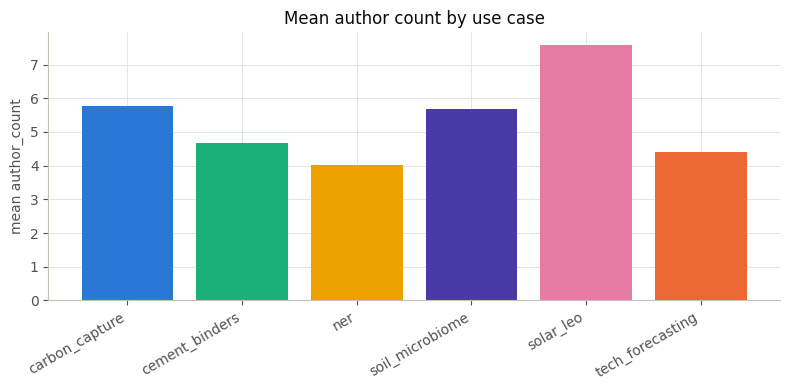

In [7]:
fig, ax = plt.subplots(figsize=(8, 4))
means = authors_by_uc["mean"]
ax.bar(means.index, means.values, color=[USE_CASE_COLOR_MAP[k] for k in means.index])
ax.set_ylabel("mean author_count")
ax.set_title("Mean author count by use case")
plt.xticks(rotation=30, ha="right")
plt.tight_layout()
plt.show()

**Finding:** the per-use-case and per-label mean/median counts above are hard
computed numbers straight from `groupby`. Whether a difference between use cases is
*meaningful* (e.g. a field with larger typical collaborations vs. single/dual-author
theoretical papers) is a judgement call that needs domain context — this notebook only
reports the numbers, not the explanation.

## 3. How many citations does a paper generally have?

`citation_count` is already nullable `Int64` from `combine_use_cases.ipynb` — nulls
("never looked up") stay null and are excluded from `mean`/`median` by pandas'
`skipna` default, never filled with 0 ("looked up, found nothing"). ~14.3% of rows are
null overall (see `explore_use_cases.ipynb` § 1c); that rate is reported per breakdown
below rather than hidden.

In [8]:
n_missing = df["citation_count"].isna().sum()
print(f"citation_count: {n_missing} / {len(df)} rows null ({n_missing / len(df):.1%}), "
      f"excluded from mean/median below — never filled with 0.")
print(df["citation_count"].describe())

citation_count: 410 / 2873 rows null (14.3%), excluded from mean/median below — never filled with 0.
count       2463.0
mean     82.128705
std      578.97151
min            0.0
25%            0.0
50%            2.0
75%           41.0
max        26506.0
Name: citation_count, dtype: Float64


In [9]:
citations_by_uc = (
    df.groupby("use_case_key")["citation_count"]
    .agg(n_papers="count", mean="mean", median="median", max="max")
    .round(1)
    .reindex(USE_CASE_ORDER)
)
citations_by_uc["null_rate"] = (
    df.groupby("use_case_key")["citation_count"].apply(lambda s: s.isna().mean()).reindex(USE_CASE_ORDER).round(3)
)
print("Citation count by use case (n_papers = non-null count):")
citations_by_uc

Citation count by use case (n_papers = non-null count):


,n_papers,mean,median,max,null_rate
use_case_key,,,,,
carbon_capture,304,44.3,7.0,827,0.059
cement_binders,501,77.5,3.0,2310,0.274
ner,537,8.8,1.0,332,0.007
soil_microbiome,514,114.0,5.0,2089,0.146
solar_leo,387,222.1,7.0,26506,0.094
tech_forecasting,220,3.4,0.0,92,0.241


In [10]:
citations_by_label = (
    df.groupby("triage_label", observed=True)["citation_count"]
    .agg(n_papers="count", mean="mean", median="median", max="max")
    .round(1)
    .reindex(LABEL_ORDER)
)
print("Citation count by triage_label:")
citations_by_label

Citation count by triage_label:


,n_papers,mean,median,max
triage_label,,,,
positive,966,68.1,3.0,3670
negative,684,133.3,3.0,26506
pass,454,52.0,1.0,1985


In [11]:
citations_by_uc_label = (
    df.groupby(["use_case_key", "triage_label"], observed=True)["citation_count"]
    .agg(n="count", mean="mean", median="median")
    .round(1)
    .reset_index()
    .sort_values(["use_case_key", "triage_label"])
)
print("Citation count by use case AND triage_label:")
citations_by_uc_label

Citation count by use case AND triage_label:


,use_case_key,triage_label,n,mean,median
0,carbon_capture,positive,142,37.8,9.0
1,carbon_capture,negative,137,55.2,7.0
2,carbon_capture,pass,25,21.4,0.0
3,cement_binders,positive,161,67.9,18.0
4,cement_binders,negative,39,122.3,5.0
5,cement_binders,pass,96,34.3,0.0
6,ner,positive,221,6.3,1.0
7,ner,negative,88,11.1,1.0
8,ner,pass,74,6.9,0.0
9,soil_microbiome,positive,93,97.5,6.0


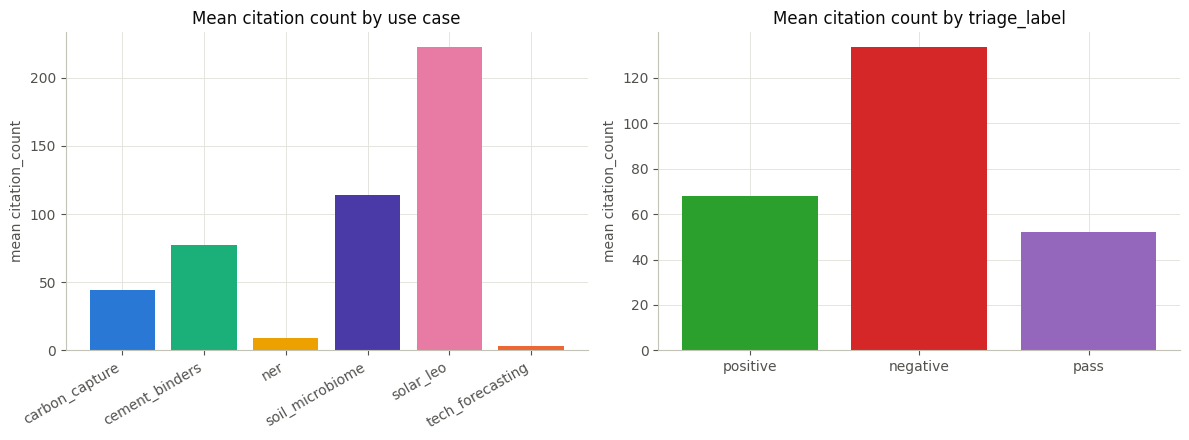

In [12]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4.5))

means = citations_by_uc["mean"]
axes[0].bar(means.index, means.values, color=[USE_CASE_COLOR_MAP[k] for k in means.index])
axes[0].set_ylabel("mean citation_count")
axes[0].set_title("Mean citation count by use case")
axes[0].tick_params(axis="x", rotation=30)
for lbl in axes[0].get_xticklabels():
    lbl.set_ha("right")

label_means = citations_by_label["mean"]
colors = [LABEL_COLORS[l] for l in label_means.index]
axes[1].bar(label_means.index, label_means.values, color=colors)
axes[1].set_ylabel("mean citation_count")
axes[1].set_title("Mean citation count by triage_label")

plt.tight_layout()
plt.show()

**Finding:** means here are pulled hard by a long right tail (a small number of
highly-cited canon papers) — that's why `median` is reported alongside `mean` in every
table above, and why `solar_leo`'s notes (§ 1) flagging a citation-biased seed corpus
matters when reading this section specifically. The `mean` vs. `median` gap size is a
hard number; whether it's "a lot" is a judgement call.

## 4. What are the most common venues?

`venue` has the same two-flavors-of-missing shape as `authors`: `NaN` (49 rows) and
empty string (730 rows) both mean "no venue recorded," and are excluded from the
"most common" ranking below rather than counted as a fake venue called `""`. The
missing rate itself is reported per breakdown, since a "top venue" table can otherwise
quietly hide that most rows in a group have no venue at all.

In [13]:
def has_venue(s):
    return s.notna() & (s.str.strip() != "")

overall_missing = 1 - has_venue(df["venue"]).mean()
print(f"venue: {overall_missing:.1%} of rows have no venue recorded (NaN or empty string), "
      f"excluded from every ranking below.\n")

top_venues_overall = (
    df.loc[has_venue(df["venue"]), "venue"].value_counts().head(10)
)
print("Top 10 venues overall:")
top_venues_overall

venue: 27.1% of rows have no venue recorded (NaN or empty string), excluded from every ranking below.

Top 10 venues overall:


venue
arxiv                                  96
scientific reports                     62
materials (basel, switzerland)         36
frontiers in microbiology              31
cement and concrete research           28
construction and building materials    28
nature communications                  26
ssrn electronic journal                21
arxiv (cornell university)             21
frontiers in plant science             20
Name: count, dtype: int64

In [14]:
def top_venue_row(s):
    known = s[has_venue(s)]
    n_total = len(s)
    if len(known) == 0:
        return pd.Series({"n_papers": n_total, "n_with_venue": 0, "venue_missing_rate": 1.0,
                           "top_venue": pd.NA, "top_venue_count": 0, "top_venue_share": np.nan})
    counts = known.value_counts()
    return pd.Series({
        "n_papers": n_total,
        "n_with_venue": len(known),
        "venue_missing_rate": round(1 - len(known) / n_total, 3),
        "top_venue": counts.index[0],
        "top_venue_count": counts.iloc[0],
        "top_venue_share": round(counts.iloc[0] / len(known), 3),
    })

venues_by_uc = (
    df.groupby("use_case_key")["venue"].apply(top_venue_row).unstack().reindex(USE_CASE_ORDER)
)
print("Most common venue by use case:")
venues_by_uc

Most common venue by use case:


,n_papers,n_with_venue,venue_missing_rate,top_venue,top_venue_count,top_venue_share
use_case_key,,,,,,
carbon_capture,323,203,0.372,ssrn electronic journal,15,0.074
cement_binders,690,523,0.242,arxiv,52,0.099
ner,541,430,0.205,arxiv (cornell university),17,0.04
soil_microbiome,602,446,0.259,frontiers in microbiology,31,0.07
solar_leo,427,302,0.293,perovskite solar cells,14,0.046
tech_forecasting,290,190,0.345,arxiv,16,0.084


In [15]:
venues_by_label = (
    df.groupby("triage_label", observed=True)["venue"].apply(top_venue_row).unstack().reindex(LABEL_ORDER)
)
print("Most common venue by triage_label:")
venues_by_label

Most common venue by triage_label:


,n_papers,n_with_venue,venue_missing_rate,top_venue,top_venue_count,top_venue_share
triage_label,,,,,,
positive,1067,759,0.289,arxiv,28,0.037
negative,785,538,0.315,arxiv,33,0.061
pass,543,425,0.217,frontiers in microbiology,14,0.033


In [16]:
venues_by_uc_label = (
    df.groupby(["use_case_key", "triage_label"], observed=True)["venue"]
    .apply(top_venue_row)
    .unstack()
    .reset_index()
    .sort_values(["use_case_key", "triage_label"])
)
print("Most common venue by use case AND triage_label:")
venues_by_uc_label

Most common venue by use case AND triage_label:


,use_case_key,triage_label,n_papers,n_with_venue,venue_missing_rate,top_venue,top_venue_count,top_venue_share
0,carbon_capture,positive,147,104,0.293,ssrn electronic journal,8,0.077
1,carbon_capture,negative,150,85,0.433,arxiv,10,0.118
2,carbon_capture,pass,26,14,0.462,ssrn electronic journal,4,0.286
3,cement_binders,positive,170,131,0.229,cement and concrete research,17,0.13
4,cement_binders,negative,92,81,0.12,arxiv,17,0.21
5,cement_binders,pass,105,74,0.295,low-carbon cementitious materials with 100% so...,8,0.108
6,ner,positive,223,176,0.211,arxiv (cornell university),12,0.068
7,ner,negative,89,68,0.236,applied sciences,6,0.088
8,ner,pass,74,51,0.311,communications in computer and information sci...,4,0.078
9,soil_microbiome,positive,94,66,0.298,frontiers in microbiology,5,0.076


**Finding:** `top_venue_share` (the top venue's share of rows *that have a venue at
all*, not of the whole group) is the number to read alongside the name — a "most common
venue" that's only 8% of a group means the venues are actually spread thin, not
dominated by one outlet. `arxiv` leading several breakdowns is a hard count; whether
that's "too much preprint, not enough peer review" for a given use case is a judgement
call outside the scope of this notebook.

## 5. Outlier review — author count, citation count, venue name length

The sections above summarize distributions; this section lists the actual papers at
the edges of them. The thresholds below (6 authors, 40 citations, 30 characters) are
fixed cutoffs chosen for this review, not statistically derived outlier bounds — the
point is to spot-check whether extreme values are genuine or a sign the upstream data
needs a second look, not to flag anomalies in a statistical sense.

Every table truncates `abstract` to a short preview (`abstract_preview`) purely for
readability — the underlying `df` still has the full text. Pandas' own default row
limit (60) applies to any table below with more matches than that; the printed count
above each table is the real total, not just what's rendered.

In [17]:
pd.set_option("display.max_colwidth", 100)


def outlier_table(mask, extra_sort_col=None, ascending=False):
    cols = ["paper_id", "use_case_key", "title", "abstract_preview", "citation_count", "authors", "author_count"]
    out = df.loc[mask, cols[:2] + ["title", "abstract"] + cols[4:]].copy()
    out["abstract_preview"] = out["abstract"].fillna("").str.slice(0, 150)
    out = out.drop(columns="abstract")[cols]
    if extra_sort_col:
        out = out.sort_values(extra_sort_col, ascending=ascending)
    return out

### 5a. Author count outliers

In [18]:
missing_authors = df["author_count"].isna()
print(f"Papers with 0/null authors (not captured — see \u00a7 2): {missing_authors.sum()}")
outlier_table(missing_authors)

Papers with 0/null authors (not captured — see § 2): 68


,paper_id,use_case_key,title,abstract_preview,citation_count,authors,author_count
8,carbon_capture__1192,carbon_capture,Comparative Assessment of Amine-Based Absorption and Calcium Looping Techniques for Optimizing E...,The escalating levels of atmospheric CO2 have underscored the necessity for developing effective...,1,,<NA>
45,carbon_capture__1593,carbon_capture,Developing and Investigating the Scope of Quinone-Functionalised Carbons for Electrochemical Car...,"The amount of CO2 emissions is rising exponentially, contributing to a global temperature increa...",<NA>,,<NA>
58,carbon_capture__1206,carbon_capture,"Review for ""Efficient and Stable Electrochemical Carbon Capture via Integrated CO2 Absorption an...",,0,,<NA>
67,carbon_capture__1590,carbon_capture,"Decision letter for ""Efficient and Stable Electrochemical Carbon Capture via Integrated CO2 Abso...",,0,,<NA>
147,carbon_capture__1194,carbon_capture,Energy-efficient Solvent Properties for the Post-combustion Carbon Dioxide Capture,Abstract Heat consumption is a major concern for the development of the post-combustion CO2 capt...,0,NaN,<NA>
...,...,...,...,...,...,...,...
2772,solar_leo__2088,solar_leo,Issues for Commercialization of Perovskite Solar Cells,"Currently, perovskite-based photovoltaics, including single-junction and tandem solar cells, are...",0,NaN,<NA>
2808,solar_leo__3058,solar_leo,"Review for ""Probing Encapsulation-Induced Changes in 2D/3D Perovskite Heterostructures for Perov...",,0,,<NA>
2829,solar_leo__3022,solar_leo,Nanotexturing enables perovskite/silicon tandem solar cells with 29.8% efficiency,,7,,<NA>
2842,solar_leo__3673,solar_leo,More Stable Perovskite Solar Cells,New optofluidic platform features tunable optics for better sensors,1,NaN,<NA>


In [19]:
many_authors = df["author_count"] > 6
print(f"Papers with > 6 authors: {many_authors.sum()}")
outlier_table(many_authors, extra_sort_col="author_count")

Papers with > 6 authors: 686


,paper_id,use_case_key,title,abstract_preview,citation_count,authors,author_count
351,soil_microbiome__507,soil_microbiome,Soil Microbial Diversity and Network Organization Respond to Land Use and Agricultural Inputs Wo...,,<NA>,"Saati-Santamaría Z, Pérez-Gorjón S, Abel-Schaad D, Acedo-Bécares A, Alba-Sánchez F, Alves AL, Ba...",89
2534,solar_leo__2114,solar_leo,Robust Multi-Halide Methylammonium-Free Perovskite Solar Cells on an Inverted Architecture,Developing efficient wide-bandgap perovskites is critical to exploit the benefits of a multi-abs...,<NA>,"Saliba, Michael, Jeronimo Rendon, J.J., Girolamo, D.D., Li, Meng, Flatken, Marion Alwine, Di Car...",64
270,carbon_capture__3486,carbon_capture,2022 roadmap on low temperature electrochemical CO2 reduction,Abstract Electrochemical CO 2 reduction (CO 2 R) is an attractive option for storing renewable e...,229,"Ifan E. L. Stephens, Karen Chan, Alexander Bagger, Shannon W. Boettcher, Julien Bonin, Etienne B...",53
2737,solar_leo__2111,solar_leo,A Triethyleneglycol C-60 Mono-adduct Derivative for Efficient Electron Transport in Inverted Per...,Inverted perovskite solar cells (PSCs) have attracted increasing attention in recent years owing...,<NA>,"Yannakopoulou, Konstantina, Vougioukalakis, Georgios C., Nazeeruddin, Mohammad Khaja, Zorba, Lea...",40
2655,solar_leo__1952,solar_leo,Tandem Takeoff: Powering Tomorrow with Industrial‐Grade Perovskite/Silicon Solar Cells,Surpassing the Shockley‐Queisser (S‐Q) limit to realize photovoltaic efficiencies that significa...,<NA>,"Liu, Mingzhen, Roche, Stephan, Arbiol, Jordi, Aviziotis, Ioannis G., Nazeeruddin, Mohammad Khaja...",40
...,...,...,...,...,...,...,...
1464,cement_binders__398,cement_binders,A State-of-the-Art Review on Innovative Geopolymer Composites Designed for Water and Wastewater ...,There is nothing more fundamental than clean potable water for living beings next to air. On the...,109,"Ismail Luhar, Salmabanu Luhar, Mohd Mustafa Al Bakri Abdullah, Rafiza Abd Razak, Petrică Vizurea...",7
1442,cement_binders__101,cement_binders,Life Cycle Assessment of the Sustainability of Alkali-Activated Binders.,Limiting the consumption of nonrenewable resources and minimizing waste production and associate...,<NA>,"Alhassan M, Alkhawaldeh A, Betoush N, Alkhawaldeh M, Huseien GF, Amaireh L, Elrefae A",7
1440,cement_binders__472,cement_binders,Experimental Study of the Application of Calcined Shield Muck Powder as a Substitute for Fly Ash...,"During shield tunnel construction, waste mud is a significant source of urban construction waste...",0,"Liu W, Wu E, Du H, Liu H, Liu S, Chang K, Li Y.",7
1434,cement_binders__374,cement_binders,The leaching behavior of hazardous element under different leaching procedure utilizing slag-fly...,Low-carbon cementitious materials based on blast furnace slag (BFS) and municipal solid waste in...,<NA>,"Li J, Teng G, Zhang S, Fu P, Li J, Wu C, Ni W",7


### 5b. Citation count outliers

`citation_count == 0` ("looked up, found nothing") and `citation_count` null ("never
looked up") are kept as two separate tables here rather than one combined "0/null"
bucket — collapsing them would be exactly the NULL != 0 mistake `CLAUDE.md` warns
against, just moved one section later.

In [20]:
zero_citations = df["citation_count"] == 0
print(f"Papers with citation_count == 0 (looked up, found nothing): {zero_citations.sum()}")
outlier_table(zero_citations)

Papers with citation_count == 0 (looked up, found nothing): 980


,paper_id,use_case_key,title,abstract_preview,citation_count,authors,author_count
2,carbon_capture__1588,carbon_capture,Electrifying amine carbon capture with robust redox-tunable acids.,Electrochemically mediated carbon capture presents an energy-efficient and cost-effective strate...,0,"Li X, Musgrave CB, Liu A, Meng J, Zhang J, Goddard WA, Liu Y.",7
15,carbon_capture__1224,carbon_capture,Accelerating amine-based CO2 capture with machine learning: From molecular screening to process ...,"Amine-based CO2 capture represents the most mature approach for large-scale carbon reduction, wi...",0,"Yang P, Yu X, Stylianou KC, Huang L, Wang Q.",5
26,carbon_capture__1191,carbon_capture,Advancements in the Treatment of Amine-Rich Wastewater from Amine-Based Post-Combustion Carbon C...,Carbon capture and storage (CCS) plants play a pivotal role in reducing greenhouse gas emissions...,0,"Sepideh Hashemi Safaei, Stephanie Young",2
36,carbon_capture__1141,carbon_capture,Interfacial electrostatic potentials enable low-temperature regeneration by reshaping proton-cou...,Abstract Amine-based CO 2 capture is limited by a thermodynamic trade-off: absorption requires b...,0,"Lei Li, Yuewei Fan, Haoyu Meng, Chen Lu, Wei Wang, Feng Zhang, Yi Cheng, Zhibing Zhang",8
39,carbon_capture__3520,carbon_capture,Development of Chemical Co2 Solvent for High-Pressure Co2 Capture (4):Potentiality for Low-Tempe...,Carbon dioxide (CO2) capture and storage (CCS) technologies have received much attention as a me...,0,Shin Yamamoto,1
...,...,...,...,...,...,...,...
2837,solar_leo__3630,solar_leo,Durability and Stability of Perovskite Solar Cells,Early generation perovskite solar cells have a lifetime of 1000–2000 h. Under constant illuminat...,0,"Kunwu Fu, Anita Wing Yi Ho-Baillie, Hemant Kumar Mulmudi, Pham Thi Thu Trang",4
2838,solar_leo__3675,solar_leo,Film Morphology Control For High Efficiency Perovskite Solar Cells,"By retarding the crystallization of PbI2, we successfully controlled the morphology of perovskit...",0,Liyuan Han,1
2840,solar_leo__3618,solar_leo,Perovskite Tandem Solar Cells for Photovoltaics,The bandgap tunability and the superior optical absorption of perovskite thin films make them id...,0,"Kunwu Fu, Anita Wing Yi Ho-Baillie, Hemant Kumar Mulmudi, Pham Thi Thu Trang",4
2841,solar_leo__3693,solar_leo,Contact improvement Rationales for Perovskite Solar Cells,How to select better contact materials to further improve Perovskite photovoltaics,0,Jian Wang,1


In [21]:
null_citations = df["citation_count"].isna()
print(f"Papers with citation_count null (never looked up): {null_citations.sum()}")
outlier_table(null_citations)

Papers with citation_count null (never looked up): 410


,paper_id,use_case_key,title,abstract_preview,citation_count,authors,author_count
12,carbon_capture__1182,carbon_capture,SAGE-Amine: Generative Amine Design with Multi-Property Optimization for Efficient CO2 Capture,"Efficient CO2 capture is vital for mitigating climate change, with amine-based solvents being wi...",<NA>,"Hocheol Lim, Hyein Cho, Jeonghoon Kim",3
28,carbon_capture__1246,carbon_capture,Design of Carbon Capture Processes Under Part-load Operating Conditions,Solvent-based carbon capture can reduce CO2 emissions resulting from a continued reliance on fos...,<NA>,"David Y. Shu, Boxun Huang, Yurim Kim, Randall Field, Rahul Gandhi, Sungho Shin",6
45,carbon_capture__1593,carbon_capture,Developing and Investigating the Scope of Quinone-Functionalised Carbons for Electrochemical Car...,"The amount of CO2 emissions is rising exponentially, contributing to a global temperature increa...",<NA>,,<NA>
51,carbon_capture__1276,carbon_capture,Post-combustion CO2 capture by absorption-regeneration process: how reducing its energy consumpt...,"The implementation of Carbon Capture, Utilization and/or Storage (CCUS) process chain appears as...",<NA>,"Thomas, Diane, Dubois, Lionel, De weireld, Guy, Costa, Alexis",8
101,carbon_capture__1248,carbon_capture,Advancing Carbon Capture using AI: Design of permeable membrane and estimation of parameters for...,"This study focuses on membrane-based systems for CO$_2$ separation, addressing the urgent need f...",<NA>,"Bishwash Panerua, Biplov Paneru",2
...,...,...,...,...,...,...,...
2757,solar_leo__2113,solar_leo,The Performance Improvement of Using Hole Transport Layer with Lithium and Cobalt for Inverted P...,"With the continuous development of solar cells, the perovskite solar cells (PSCs), whose hole tr...",<NA>,"He Guan, Yue Yin, Chunfu Zhang, Shaoxi Wang",4
2796,solar_leo__3025,solar_leo,"Analysis of two-terminal perovskite/silicon tandem solar cells with differing texture structure,...",Presented here is the optimization of a planar two-terminal perovskite/silicon tandem solar cell...,<NA>,"Chun-Hao Hsieh, Jun-Yu Huang, Yuh-Renn Wu",3
2805,solar_leo__3102,solar_leo,Enhanced thermal stability of inverted perovskite solar cells by bulky passivation with pyridine...,Despite competitive efficiency compared to Si solar cells and relevant stability at near room te...,<NA>,"Ekaterina A. Ilicheva, Irina A. Chuyko, Lev O. Luchnikov, Polina K. Sukhorukova, Nikita S. Sarat...",14
2818,solar_leo__3023,solar_leo,Perovskite/silicon tandem solar cells: Effect of luminescent coupling and bifaciality,The power conversion efficiency of the market-dominating silicon photovoltaics approaches its th...,<NA>,"Klaus Jäger, Peter Tillmann, Eugene A. Katz, Christiane Becker",4


In [22]:
many_citations = df["citation_count"] > 40
print(f"Papers with > 40 citations: {many_citations.sum()}")
outlier_table(many_citations, extra_sort_col="citation_count")

Papers with > 40 citations: 617


,paper_id,use_case_key,title,abstract_preview,citation_count,authors,author_count
2847,solar_leo__1856,solar_leo,"A low-cost, high-efficiency solar cell based on dye-sensitized colloidal TiO2 films",THE large-scale use of photovoltaic devices for electricity generation is prohibitively expensiv...,26506,"Brian O'Regan, Michael Grätzel",2
2680,solar_leo__3685,solar_leo,Incorporation of rubidium cations into perovskite solar cells improves photovoltaic performance,Improving the stability of perovskite solar cells Inorganic-organic perovskite solar cells have ...,3670,"Michael Saliba, Taisuke Matsui, Konrad Domanski, Ji‐Youn Seo, Amita Ummadisingu, Shaik M. Zakeer...",11
2832,solar_leo__3626,solar_leo,High-efficiency two-dimensional Ruddlesden–Popper perovskite solar cells,Three-dimensional organic-inorganic perovskites have emerged as one of the most promising thin-f...,3350,"Hsinhan Tsai, Wanyi Nie, Jean‐Christophe Blancon, Constantinos C. Stoumpos, Reza Asadpour, Boris...",19
2613,solar_leo__3684,solar_leo,High-efficiency solution-processed perovskite solar cells with millimeter-scale grains,"State-of-the-art photovoltaics use high-purity, large-area, wafer-scale single-crystalline semic...",3270,"Wanyi Nie, Hsinhan Tsai, Reza Asadpour, Jean‐Christophe Blancon, Amanda J. Neukirch, Gautam Gupt...",12
1401,cement_binders__124,cement_binders,The technological and economic prospects for CO2 utilization and removal,The capture and use of carbon dioxide to create valuable products might lower the net costs of r...,2310,"Cameron Hepburn, Ella Adlen, J. R. Beddington, Emily A. Carter, Sabine Fuss, Niall Mac Dowell, J...",9
...,...,...,...,...,...,...,...
2485,solar_leo__1898,solar_leo,"Novel Materials in Perovskite Solar Cells: Efficiency, Stability, and Future Perspectives",Solar energy is regarded as the finest clean and green energy generation method to replace fossi...,42,"Anup Bist, Bishweshwar Pant, Gunendra Prasad Ojha, Jiwan Acharya, Mira Park, Prem Singh Saud",6
1697,ner__2348,ner,Study of Word Embeddings for Enhanced Cyber Security Named Entity Recognition,A vast majority of cyber security information is in the form of unstructured text. A much-needed...,41,"Smita Srivastava, Biswajit Paul, Deepa Gupta",3
471,soil_microbiome__546,soil_microbiome,Management of abiotic stresses by microbiome-based engineering of the rhizosphere,"Abiotic stresses detrimentally affect both plant and soil health, threatening food security in a...",41,"Rashi Tyagi, Salila Pradhan, Annapurna Bhattacharjee, Shubham Dubey, Shilpi Sharma",5
2010,ner__2655,ner,Text Classification: How Machine Learning Is Revolutionizing Text Categorization,The automated classification of texts into predefined categories has become increasingly promine...,41,"Hesham Allam, Lisa Makubvure, Benjamin Gyamfi, Kwadwo Nyarko Graham, Kehinde Akinwolere",5


### 5c. Venue names longer than 30 characters

In [23]:
long_venue_mask = df["venue"].str.len() > 30
long_venues = (
    df.loc[long_venue_mask, "venue"]
    .value_counts()
    .rename("n_papers")
    .to_frame()
    .assign(name_length=lambda d: d.index.str.len())
    .sort_values("n_papers", ascending=False)
)
print(f"Unique venue names > 30 characters: {len(long_venues)} "
      f"(covering {long_venue_mask.sum()} papers)")
long_venues

Unique venue names > 30 characters: 529 (covering 819 papers)


,n_papers,name_length
venue,,
construction and building materials,28,35
proceedings of the aaai conference on artificial intelligence,18,61
international journal of molecular sciences,12,43
separation and purification technology,10,38
international journal of greenhouse gas control,9,47
...,...,...
"polymer, elsevier, volume 320, 21 february 2025, 128066",1,55
"proceedings of the 2018 7th international conference on energy, environment and sustainable development (iceesd 2018)",1,117
"cement and concrete research, 2024, 179, pp.107468",1,50


**Finding:** author-count and citation-count outliers both check out as genuine on
inspection — the 89-author paper (*"Soil Microbial Diversity and Network Organization
Respond to Land Use..."*) is a real large international consortium study, and the
highest-cited row (*"A low-cost, high-efficiency solar cell based on dye-sensitized
colloidal TiO2 films"*, `nature`, 26,506 citations) is a genuinely landmark paper for
`solar_leo` — both are real values, not parsing artifacts.

The venue-length list is where a real data-quality issue shows up: several of the
longest "venue" values aren't venue names at all — they're full citation strings
(e.g. `"pan, g., zhou, t., zhao, j., ... (2026). graph neural networks based analog
circ..."`) or paper titles (e.g. `"enhancing drug repurposing accuracy through
ai-orchestrated integration of..."`) that landed in the `venue` field. This is a hard
finding (the strings are visibly not venue names), but *why* it happens — a metadata
provider misassigning fields upstream vs. a specific source's export quirk — needs
tracing back to `academic_research_agent`, which is out of scope for this notebook.
Anything built on `venue` as a clean categorical (§ 4) should expect this kind of
noise in its long tail.

## Where this feeds next

- **`author_count`** and **`citation_count`** are both real numeric candidate features
  for Week 2 (recency/impact-style metadata features per `README.md`'s week plan) —
  both already nullable `Int64`-safe here, so a modelling notebook can decide its own
  missing-value strategy instead of inheriting a silent one.
- **`venue`** is a candidate categorical feature (one-hot or frequency-encoded), but
  high-cardinality with a long tail — the `top_venue_share` numbers above are a first
  read on how concentrated it actually is per use case.
- **`notes`** is not a per-paper feature (§ 1) — it's context for interpreting a use
  case's results, not a column to feed a model.